<a href="https://colab.research.google.com/github/ugisrutinsRSU/RSU_Colab/blob/main/07_lstm_text_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN/LSTM for Text: From Raw Text to Next-Word Prediction

**Learning objectives**

By the end of this exercise you will be able to:

1. Build a naive vocabulary and tokenizer from raw text.
2. Convert text into integer sequences suitable for an RNN.
3. Define and train a small LSTM model in PyTorch for next-word prediction.
4. Use the trained model to generate new text.

> ⚠️ This is a **teaching notebook**. The dataset is tiny and the model is small, so do not expect Shakespeare-level prose — the goal is to understand the full pipeline end-to-end.

---

## 1. The raw text

We start with a short corpus. In a real project this would be a book, a collection of tweets, scientific abstracts, etc. For now we use a small hand-written paragraph so the training runs in seconds.

In [1]:
# Our tiny training corpus — in a real project this would be a book or dataset file.
# The more text you provide, the better the model can learn word patterns.
raw_text = """
The cat sat on the mat. The cat looked at the dog.
The dog sat on the floor. The dog looked at the cat.
A small cat and a big dog became friends.
The cat and the dog played on the mat together.
The mat was warm and the floor was cold.
The friends slept on the warm mat every night.
"""

print(raw_text)
print(f"Number of characters: {len(raw_text)}")


The cat sat on the mat. The cat looked at the dog.
The dog sat on the floor. The dog looked at the cat.
A small cat and a big dog became friends.
The cat and the dog played on the mat together.
The mat was warm and the floor was cold.
The friends slept on the warm mat every night.

Number of characters: 283


## 2. Naive preprocessing and tokenization

We will do **word-level tokenization** with a very simple recipe:

- lowercase everything,
- strip punctuation,
- split on whitespace.

This is deliberately naive (no stemming, no subwords, no handling of contractions). It is enough to illustrate the pipeline.

In [2]:
import re

def simple_tokenize(text: str) -> list[str]:
    # Step 1: lowercase so "The" and "the" map to the same token
    text = text.lower()
    # Step 2: replace anything that's not a letter or whitespace with a space
    #         this removes punctuation like "." "," without losing word boundaries
    text = re.sub(r"[^a-z\s]", " ", text)
    # Step 3: split on whitespace — multiple spaces are handled automatically
    tokens = text.split()
    return tokens

tokens = simple_tokenize(raw_text)
print(f"First 20 tokens: {tokens[:20]}")
print(f"Total tokens:    {len(tokens)}")

First 20 tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'the', 'cat', 'looked', 'at', 'the', 'dog', 'the', 'dog', 'sat', 'on', 'the', 'floor', 'the', 'dog']
Total tokens:    61


## 3. Building the vocabulary

We map each unique token to an integer id. We also reserve two special tokens:

- `<pad>` (id 0) — for padding shorter sequences,
- `<unk>` (id 1) — for words not seen during training.

In [3]:
from collections import Counter

# Count how often each word appears — frequent words get lower ids (better for embeddings)
counter = Counter(tokens)
print("Word frequencies:")
for w, c in counter.most_common():
    print(f"  {w:10s} {c}")

# <pad> (id=0): used to fill shorter sequences to a fixed length
# <unk> (id=1): used at inference time for words the model has never seen
specials = ["<pad>", "<unk>"]
vocab = specials + [w for w, _ in counter.most_common()]

# word2idx: look up a word's integer id  ("cat" -> 3)
# idx2word: reverse lookup for decoding  (3 -> "cat")
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

vocab_size = len(vocab)
print(f"\nVocabulary size (incl. specials): {vocab_size}")
print(f"First 10 entries: {vocab[:10]}")

Word frequencies:
  the        15
  cat        5
  dog        5
  on         4
  mat        4
  and        3
  sat        2
  looked     2
  at         2
  floor      2
  a          2
  friends    2
  was        2
  warm       2
  small      1
  big        1
  became     1
  played     1
  together   1
  cold       1
  slept      1
  every      1
  night      1

Vocabulary size (incl. specials): 25
First 10 entries: ['<pad>', '<unk>', 'the', 'cat', 'dog', 'on', 'mat', 'and', 'sat', 'looked']


## 4. Encoding text into integer sequences

We now turn the token list into a list of ids. Then we slice it into fixed-length **input/target** pairs for next-word prediction:

- given a context of `seq_len` words,
- predict the single next word.

So if `seq_len = 4` and the sentence is `the cat sat on the mat`, we generate:

| Input (x)             | Target (y) |
|-----------------------|------------|
| the, cat, sat, on     | the        |
| cat, sat, on, the     | mat        |

In [4]:
def encode(tokens: list[str]) -> list[int]:
    # Convert each word to its integer id.
    # .get(t, word2idx["<unk>"]) means: if the word is not in vocab, use id 1 (<unk>)
    return [word2idx.get(t, word2idx["<unk>"]) for t in tokens]

encoded = encode(tokens)
print(f"First 20 ids: {encoded[:20]}")
# Decode back to verify the mapping is correct
print(f"Decoded back: {[idx2word[i] for i in encoded[:20]]}")

First 20 ids: [2, 3, 8, 5, 2, 6, 2, 3, 9, 10, 2, 4, 2, 4, 8, 5, 2, 11, 2, 4]
Decoded back: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'the', 'cat', 'looked', 'at', 'the', 'dog', 'the', 'dog', 'sat', 'on', 'the', 'floor', 'the', 'dog']


In [5]:
import torch

# How many past words the model sees at once when predicting the next word
SEQ_LEN = 4

def make_pairs(encoded: list[int], seq_len: int):
    xs, ys = [], []
    # Slide a window of size seq_len across the token list.
    # Each window becomes one training example: input=window, target=next token.
    for i in range(len(encoded) - seq_len):
        xs.append(encoded[i : i + seq_len])   # input context
        ys.append(encoded[i + seq_len])        # word to predict
    return torch.tensor(xs, dtype=torch.long), torch.tensor(ys, dtype=torch.long)

X, y = make_pairs(encoded, SEQ_LEN)
print(f"X shape: {tuple(X.shape)}  (n_samples, seq_len)")
print(f"y shape: {tuple(y.shape)}  (n_samples,)")

# Peek at the first training pair
print("\nExample pair:")
print("  x:", [idx2word[i.item()] for i in X[0]])
print("  y:", idx2word[y[0].item()])

X shape: (57, 4)  (n_samples, seq_len)
y shape: (57,)  (n_samples,)

Example pair:
  x: ['the', 'cat', 'sat', 'on']
  y: the


## 5. Defining the LSTM model

The architecture is minimal:

1. **Embedding layer** — maps each word id to a dense vector of size `embed_dim`.
2. **LSTM layer** — processes the sequence and produces a hidden state per timestep.
3. **Linear layer** — projects the last hidden state to a vector of size `vocab_size` (the logits over the vocabulary).

We only use the last timestep's output because we are predicting a single next word.

In [6]:
import torch.nn as nn

class WordLSTM(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 32, hidden_dim: int = 64):
        super().__init__()
        # Embedding: turns each integer word-id into a dense vector of size embed_dim.
        # padding_idx=0 means the <pad> token's embedding is always kept as zeros.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # LSTM: reads the sequence of embeddings and outputs a hidden state at each step.
        # batch_first=True means input shape is (batch, seq_len, features).
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        # Linear head: maps the last hidden state to a score for every word in the vocab.
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)              # (batch, seq_len, embed_dim)
        out, (h, c) = self.lstm(emb)         # out: (batch, seq_len, hidden_dim)
        last = out[:, -1, :]                 # take only the last timestep's output
        logits = self.fc(last)               # (batch, vocab_size) — raw unnormalized scores
        return logits

torch.manual_seed(0)
model = WordLSTM(vocab_size=vocab_size, embed_dim=32, hidden_dim=64)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTrainable parameters: {n_params:,}")

WordLSTM(
  (embedding): Embedding(25, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=25, bias=True)
)

Trainable parameters: 27,513


## 6. Training loop

We use:

- **CrossEntropyLoss** — standard for classification over `vocab_size` classes,
- **Adam optimizer** with a moderate learning rate,
- full-batch training (the dataset is tiny, no need for mini-batches).

In [7]:
# CrossEntropyLoss = softmax + negative log-likelihood; standard for multi-class prediction
criterion = nn.CrossEntropyLoss()
# Adam adapts the learning rate per-parameter, generally converges faster than plain SGD
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 200
history = []  # store loss each epoch so we can plot it later

model.train()  # activates dropout/batchnorm layers (none here, but good practice)
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()       # clear gradients from the previous step
    logits = model(X)           # forward pass: (n_samples, vocab_size)
    loss = criterion(logits, y) # compare predictions to ground-truth next words
    loss.backward()             # backprop: compute d(loss)/d(params) for every parameter
    optimizer.step()            # gradient descent: nudge every parameter to reduce loss

    history.append(loss.item())

    if epoch == 1 or epoch % 20 == 0:
        # argmax gives the word with the highest predicted score
        preds = logits.argmax(dim=-1)
        acc = (preds == y).float().mean().item()
        print(f"Epoch {epoch:3d} | loss = {loss.item():.4f} | train acc = {acc:.2%}")

Epoch   1 | loss = 3.1975 | train acc = 14.04%
Epoch  20 | loss = 0.3159 | train acc = 98.25%
Epoch  40 | loss = 0.0077 | train acc = 100.00%
Epoch  60 | loss = 0.0023 | train acc = 100.00%
Epoch  80 | loss = 0.0015 | train acc = 100.00%


Epoch 100 | loss = 0.0012 | train acc = 100.00%
Epoch 120 | loss = 0.0010 | train acc = 100.00%
Epoch 140 | loss = 0.0009 | train acc = 100.00%
Epoch 160 | loss = 0.0008 | train acc = 100.00%
Epoch 180 | loss = 0.0007 | train acc = 100.00%


Epoch 200 | loss = 0.0006 | train acc = 100.00%


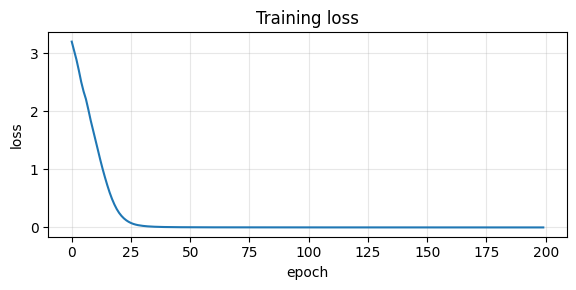

In [8]:
# A healthy training curve falls steeply then levels off (no divergence, no plateau too early).
# If the curve never decreases, the learning rate is too high or the model is too small.
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.plot(history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Using the model: next-word prediction

Given some seed text, we:

1. tokenize it,
2. keep the last `SEQ_LEN` tokens as context,
3. run the model and take the **argmax** over logits to get the predicted next word.

For a bit of variety we also provide a **sampling** version that draws from the softmax distribution with temperature.

In [9]:
model.eval()  # disable dropout/batchnorm training behaviour during inference

def predict_next(seed: str, strategy: str = "argmax", temperature: float = 1.0) -> str:
    toks = simple_tokenize(seed)
    # If seed is shorter than SEQ_LEN, left-pad with <pad> so the input shape is correct
    if len(toks) < SEQ_LEN:
        toks = ["<pad>"] * (SEQ_LEN - len(toks)) + toks
    # Only keep the most recent SEQ_LEN words as context
    context = toks[-SEQ_LEN:]
    ids = torch.tensor([encode(context)], dtype=torch.long)  # shape: (1, SEQ_LEN)

    with torch.no_grad():  # no gradient computation needed at inference time
        logits = model(ids).squeeze(0)   # (vocab_size,)

    if strategy == "argmax":
        # Deterministic: always pick the single most likely word
        next_id = logits.argmax().item()
    elif strategy == "sample":
        # Stochastic: draw from the probability distribution.
        # temperature < 1 makes it more confident; temperature > 1 makes it more random.
        probs = torch.softmax(logits / temperature, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()
    else:
        raise ValueError(strategy)

    return idx2word[next_id]

# Try a few seeds
for seed in ["the cat sat on", "the dog looked at", "a small cat and"]:
    nxt = predict_next(seed, strategy="argmax")
    print(f"'{seed}' -> '{nxt}'")

'the cat sat on' -> 'the'
'the dog looked at' -> 'the'
'a small cat and' -> 'a'


In [10]:
def generate(seed: str, n_words: int = 10, strategy: str = "argmax", temperature: float = 1.0) -> str:
    out_tokens = simple_tokenize(seed)
    for _ in range(n_words):
        # Predict one word at a time, then append it and slide the context forward
        nxt = predict_next(" ".join(out_tokens), strategy=strategy, temperature=temperature)
        out_tokens.append(nxt)
    return " ".join(out_tokens)

# Greedy (argmax): always picks the most probable next word — deterministic but can loop
print("Greedy (argmax) generation:")
print("  ", generate("the cat sat", n_words=12, strategy="argmax"))

# Sampling with temperature=0.8: slightly sharpens the distribution before drawing,
# giving more variety while still preferring likely words
print("\nSampled generation (temperature=0.8):")
torch.manual_seed(42)  # fix seed for reproducibility
print("  ", generate("the cat sat", n_words=12, strategy="sample", temperature=0.8))

Greedy (argmax) generation:
   the cat sat the dog played on the mat together the mat was warm and

Sampled generation (temperature=0.8):
   the cat sat the dog played on the mat together the mat was warm and
